In [1]:
!pip install monai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 11.0 MB/s eta 0:00:0000:0100:01


In [2]:
import os
import sys

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torch.autograd import Variable

import numpy as np
import pandas as pd

import math

from functools import partial
from sklearn import metrics
import matplotlib.pyplot as plt

In [9]:
tensor_path = '/kaggle/input/datasets/arinehkhachikian/adni-alzheimer-tensors'
tensors_dir = '/kaggle/input/datasets/arinehkhachikian/adni-alzheimer-tensors/tensors/tensors'

In [4]:
# resnet.py

__all__ = [
    'ResNet', 'resnet10', 'resnet18', 'resnet34', 'resnet50', 'resnet101',
    'resnet152', 'resnet200'
]


def conv3x3x3(in_planes, out_planes, stride=1, dilation=1):
    # 3x3x3 convolution with padding
    return nn.Conv3d(
        in_planes,
        out_planes,
        kernel_size=3,
        dilation=dilation,
        stride=stride,
        padding=dilation,
        bias=False)


def downsample_basic_block(x, planes, stride, no_cuda=False):
    out = F.avg_pool3d(x, kernel_size=1, stride=stride)
    zero_pads = torch.Tensor(
        out.size(0), planes - out.size(1), out.size(2), out.size(3),
        out.size(4)).zero_()
    if not no_cuda:
        if isinstance(out.data, torch.cuda.FloatTensor):
            zero_pads = zero_pads.cuda()

    out = Variable(torch.cat([out.data, zero_pads], dim=1))

    return out


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, dilation=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = conv3x3x3(inplanes, planes, stride=stride, dilation=dilation)
        self.bn1 = nn.BatchNorm3d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3x3(planes, planes, dilation=dilation)
        self.bn2 = nn.BatchNorm3d(planes)
        self.downsample = downsample
        self.stride = stride
        self.dilation = dilation

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out += residual
        out = self.relu(out)

        return out


class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1, dilation=1, downsample=None):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv3d(inplanes, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm3d(planes)
        self.conv2 = nn.Conv3d(
            planes, planes, kernel_size=3, stride=stride, dilation=dilation, padding=dilation, bias=False)
        self.bn2 = nn.BatchNorm3d(planes)
        self.conv3 = nn.Conv3d(planes, planes * 4, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm3d(planes * 4)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride
        self.dilation = dilation

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out += residual
        out = self.relu(out)

        return out


class ResNet(nn.Module):

    def __init__(self,
                 block,
                 layers,
                 sample_input_D,
                 sample_input_H,
                 sample_input_W,
                 num_seg_classes,
                 shortcut_type='B',
                 no_cuda = False):
        self.inplanes = 64
        self.no_cuda = no_cuda
        super(ResNet, self).__init__()
        self.conv1 = nn.Conv3d(
            1,
            64,
            kernel_size=7,
            stride=(2, 2, 2),
            padding=(3, 3, 3),
            bias=False)
            
        self.bn1 = nn.BatchNorm3d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool3d(kernel_size=(3, 3, 3), stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0], shortcut_type)
        self.layer2 = self._make_layer(
            block, 128, layers[1], shortcut_type, stride=2)
        self.layer3 = self._make_layer(
            block, 256, layers[2], shortcut_type, stride=1, dilation=2)
        self.layer4 = self._make_layer(
            block, 512, layers[3], shortcut_type, stride=1, dilation=4)

        self.conv_seg = nn.Sequential(
                                        nn.ConvTranspose3d(
                                        512 * block.expansion,
                                        32,
                                        2,
                                        stride=2
                                        ),
                                        nn.BatchNorm3d(32),
                                        nn.ReLU(inplace=True),
                                        nn.Conv3d(
                                        32,
                                        32,
                                        kernel_size=3,
                                        stride=(1, 1, 1),
                                        padding=(1, 1, 1),
                                        bias=False), 
                                        nn.BatchNorm3d(32),
                                        nn.ReLU(inplace=True),
                                        nn.Conv3d(
                                        32,
                                        num_seg_classes,
                                        kernel_size=1,
                                        stride=(1, 1, 1),
                                        bias=False) 
                                        )

        for m in self.modules():
            if isinstance(m, nn.Conv3d):
                m.weight = nn.init.kaiming_normal(m.weight, mode='fan_out')
            elif isinstance(m, nn.BatchNorm3d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()

    def _make_layer(self, block, planes, blocks, shortcut_type, stride=1, dilation=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            if shortcut_type == 'A':
                downsample = partial(
                    downsample_basic_block,
                    planes=planes * block.expansion,
                    stride=stride,
                    no_cuda=self.no_cuda)
            else:
                downsample = nn.Sequential(
                    nn.Conv3d(
                        self.inplanes,
                        planes * block.expansion,
                        kernel_size=1,
                        stride=stride,
                        bias=False), nn.BatchNorm3d(planes * block.expansion))

        layers = []
        layers.append(block(self.inplanes, planes, stride=stride, dilation=dilation, downsample=downsample))
        self.inplanes = planes * block.expansion
        for i in range(1, blocks):
            layers.append(block(self.inplanes, planes, dilation=dilation))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.conv_seg(x)

        return x

def resnet10(**kwargs):
    """Constructs a ResNet-18 model.
    """
    model = ResNet(BasicBlock, [1, 1, 1, 1], **kwargs)
    return model


def resnet18(**kwargs):
    """Constructs a ResNet-18 model.
    """
    model = ResNet(BasicBlock, [2, 2, 2, 2], **kwargs)
    return model


def resnet34(**kwargs):
    """Constructs a ResNet-34 model.
    """
    model = ResNet(BasicBlock, [3, 4, 6, 3], **kwargs)
    return model


def resnet50(**kwargs):
    """Constructs a ResNet-50 model.
    """
    model = ResNet(Bottleneck, [3, 4, 6, 3], **kwargs)
    return model


def resnet101(**kwargs):
    """Constructs a ResNet-101 model.
    """
    model = ResNet(Bottleneck, [3, 4, 23, 3], **kwargs)
    return model


def resnet152(**kwargs):
    """Constructs a ResNet-101 model.
    """
    model = ResNet(Bottleneck, [3, 8, 36, 3], **kwargs)
    return model


def resnet200(**kwargs):
    """Constructs a ResNet-101 model.
    """
    model = ResNet(Bottleneck, [3, 24, 36, 3], **kwargs)
    return model

In [5]:
# get_medicalnet()

def get_medicalnet(pretrained_path, num_classes=3, device='cpu'):
    # Load ResNet10 architecture
    model = resnet10(
        sample_input_W = 128,
        sample_input_H = 128,
        sample_input_D = 128,
        shortcut_type = 'B',
        no_cuda=(device == 'cpu'),
        num_seg_classes = num_classes
    )

    # Load pretrained weights
    checkpoint = torch.load(pretrained_path, map_location = device)
    state_dict = checkpoint['state_dict']

    # Remove 'module.' prefix if present (from DataParallel training)
    new_state_dict = {}
    for k, v in state_dict.items():
        name = k.replace('module.', '')
        new_state_dict[name] = v

    # Load weights with strict=False to allow mismatched final layer
    model.load_state_dict(new_state_dict, strict=False)

    # Replace final segmentation layer with classification layer
    model.conv_seg = nn.Sequential(
        nn.AdaptiveAvgPool3d((1, 1, 1)),
        nn.Flatten(),
        nn.Linear(512, num_classes)
    )

    return model

def get_medicalnet_multimodal(pretrained_path, num_clinical_features=5, num_classes=2, device='cpu'):
    # Load base ResNet10
    backbone = resnet10(
        sample_input_W=128,
        sample_input_H=128,
        sample_input_D=128,
        shortcut_type='B',
        no_cuda=(device == 'cpu'),
        num_seg_classes=num_classes
    )

    # Load pretrained weights
    checkpoint = torch.load(pretrained_path, map_location=device, weights_only=False)
    state_dict = checkpoint['state_dict']
    new_state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
    backbone.load_state_dict(new_state_dict, strict=False)

    # Build multimodal model
    class MultimodalResNet(nn.Module):
        def __init__(self, backbone, num_clinical_features, num_classes):
            super().__init__()
            # Image feature extractor — everything except final layer
            self.image_encoder = nn.Sequential(
                backbone.conv1,
                backbone.bn1,
                backbone.relu,
                backbone.maxpool,
                backbone.layer1,
                backbone.layer2,
                backbone.layer3,
                backbone.layer4,
                nn.AdaptiveAvgPool3d((1, 1, 1)),
                nn.Flatten()
            )
            # Clinical feature encoder
            self.clinical_encoder = nn.Sequential(
                nn.Linear(num_clinical_features, 32),
                nn.ReLU(),
                nn.Linear(32, 32)
            )
            # Fusion classifier
            self.classifier = nn.Sequential(
                nn.Linear(512 + 32, 128),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(128, num_classes)
            )

        def forward(self, image, clinical):
            img_features = self.image_encoder(image)
            clin_features = self.clinical_encoder(clinical)
            combined = torch.cat([img_features, clin_features], dim=1)
            return self.classifier(combined)

    model = MultimodalResNet(backbone, num_clinical_features, num_classes)
    return model

In [6]:
# evaluate.py

def evaluate(model, test_loader, device):
    model.eval()
    all_predictions = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, clinical, labels in test_loader:
            images = images.to(device)
            clinical = clinical.to(device)
            labels = labels.to(device)

            outputs = model(images, clinical)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return all_predictions, all_labels, all_probs

def compute_metrics(all_predictions, all_labels):

    class_names = ['CN', 'Dementia']

    # Classification report
    print("Classification report:")
    print(metrics.classification_report(all_labels, all_predictions, target_names=class_names))

    # Overall accuracy
    accuracy = metrics.accuracy_score(all_labels, all_predictions)
    print(f"Overall accuracy: {accuracy:.4f}")

    # Confusion matrix
    cm = metrics.confusion_matrix(all_labels, all_predictions)

    # Plot confusion matrix
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = metrics.ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, cmap='Blues')
    plt.title('Confusion Matrix — Test Set')
    plt.tight_layout()
    plt.savefig('/kaggle/working/figures/confusion_matrix.png', dpi=150)
    plt.show()
    
    return accuracy, cm

def compute_auc(all_labels, all_probs):
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # For binary classification, use probability of positive class (Dementia)
    auc = metrics.roc_auc_score(all_labels, all_probs[:, 1])
    print(f"Macro AUC-ROC: {auc:.4f}")
    
    return auc

def bootstrap_confidence_interval(all_labels, all_predictions, n_bootstrap=1000, ci=0.95):
    all_labels = np.array(all_labels)
    all_predictions = np.array(all_predictions)
    
    bootstrap_accuracies = []
    n = len(all_labels)
    
    for _ in range(n_bootstrap):
        # Sample with replacement
        indices = np.random.choice(n, n, replace=True)
        boot_labels = all_labels[indices]
        boot_preds = all_predictions[indices]
        acc = metrics.accuracy_score(boot_labels, boot_preds)
        bootstrap_accuracies.append(acc)
    
    lower = np.percentile(bootstrap_accuracies, (1 - ci) / 2 * 100)
    upper = np.percentile(bootstrap_accuracies, (1 + ci) / 2 * 100)
    
    print(f"Accuracy: {metrics.accuracy_score(all_labels, all_predictions):.4f}")
    print(f"95% Confidence Interval: [{lower:.4f}, {upper:.4f}]")
    
    return lower, upper

In [7]:
# TensorDataset Class

class TensorDataset(Dataset):
    def __init__(self, dataframe, tensors_dir):
        self.data = dataframe.reset_index(drop=True)
        self.tensors_dir = tensors_dir

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        ptid = row['PTID']
        label = int(row['label'])
        
        # Load preprocessed tensor file
        tensor_path = os.path.join(self.tensors_dir, f'{ptid}.pt')
        sample = torch.load(tensor_path)
        volume = sample['volume']
        
        return volume, label

class MultimodalDataset(Dataset):
    def __init__(self, dataframe, tensors_dir, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.tensors_dir = tensors_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        ptid = row['PTID']
        label = int(row['label'])

        # Load preprocessed tensor
        tensor_path = os.path.join(self.tensors_dir, f'{ptid}.pt')
        sample = torch.load(tensor_path, weights_only=False)
        volume = sample['volume']

        # Clinical features: age, sex, education
        age = float(row['AGE']) if pd.notna(row['AGE']) else 0.0
        sex = 1.0 if row['PTGENDER'] == 'Male' else 0.0
        edu = float(row['PTEDUCAT']) if pd.notna(row['PTEDUCAT']) else 0.0

        clinical = torch.tensor([age, sex, edu], dtype=torch.float32)

        return volume, clinical, label

In [10]:
test_df = pd.read_csv(f'{tensor_path}/test_binary_multi.csv')
test_dataset = MultimodalDataset(test_df, tensors_dir)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False)
print(f"Test subjects: {len(test_dataset)}")

Test subjects: 92


In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pretrained_path = f'{tensor_path}/resnet_10_23dataset.pth'
checkpoint_path = f'{tensor_path}/best_model_no_scores.pt'

model = get_medicalnet_multimodal(pretrained_path, num_clinical_features=3, num_classes=2, device=str(device)).to(device)
model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=False))
model.eval()
print("Model loaded successfully")

/tmp/ipykernel_58/2437442866.py:168: FutureWarning: `nn.init.kaiming_normal` is now deprecated in favor of `nn.init.kaiming_normal_`.
  m.weight = nn.init.kaiming_normal(m.weight, mode='fan_out')


Model loaded successfully


In [12]:
all_predictions, all_labels, all_probs = evaluate(model, test_loader, device)

Classification report:
              precision    recall  f1-score   support

          CN       0.76      1.00      0.86        70
    Dementia       0.00      0.00      0.00        22

    accuracy                           0.76        92
   macro avg       0.38      0.50      0.43        92
weighted avg       0.58      0.76      0.66        92

Overall accuracy: 0.7609


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


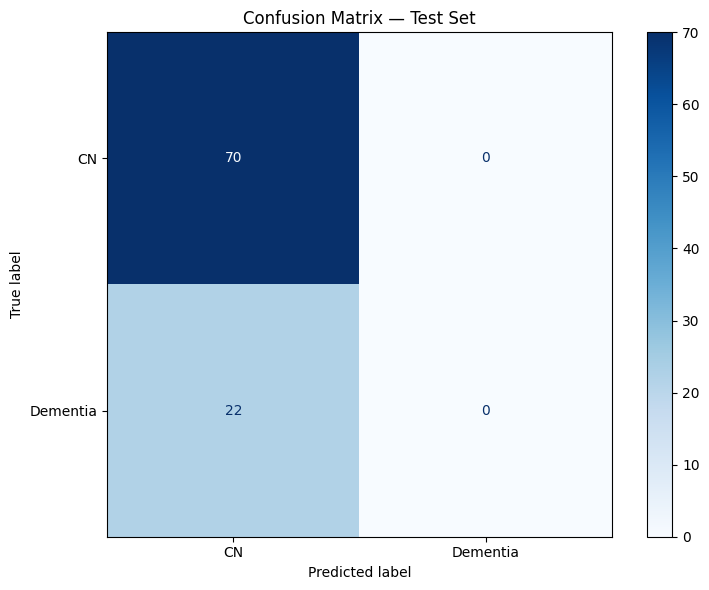

AUC-ROC: 0.6994
Accuracy: 0.7609
95% Confidence Interval: [0.6739, 0.8478]


In [13]:
os.makedirs('/kaggle/working/figures', exist_ok=True)

accuracy, cm = compute_metrics(all_predictions, all_labels)
all_probs = np.array(all_probs)
auc = metrics.roc_auc_score(all_labels, all_probs[:, 1])
print(f"AUC-ROC: {auc:.4f}")
lower, upper = bootstrap_confidence_interval(all_labels, all_predictions)